In [1]:
import glob, io, os
import pandas as pd, requests

API = "https://data.humdata.org/api/3/action/package_show?id=wfp-food-prices-for-nigeria"
HEADERS = {"User-Agent": "Mozilla/5.0 (research notebook)"}

info = requests.get(API, headers=HEADERS, timeout=60).json()["result"]
print("Dataset:", info["title"])
print("Source:", info.get("dataset_source"), "| licence:", info.get("license_title"))
for r in info["resources"]:
    print("  file:", r["name"], "|", r["format"], "|", r["url"])

Dataset: Nigeria - Food Prices
Source: FEWSNET via FAO: GIEWS, FPMA, Nigeria, SIMA - Niger, WFP | licence: Creative Commons Attribution for Intergovernmental Organisations (CC BY-IGO)
  file: Nigeria - Food Prices | CSV | https://data.humdata.org/dataset/42db041f-7aaf-4ab4-961f-2a12096861e7/resource/12b51155-0cd3-4806-9924-61ede4077591/download/wfp_food_prices_nga.csv
  file: Nigeria - Markets | CSV | https://data.humdata.org/dataset/42db041f-7aaf-4ab4-961f-2a12096861e7/resource/5329e772-0b74-4f65-8cc0-37a0915cc7e4/download/wfp_markets_nga.csv


In [2]:
def is_csv(r):
    return r["format"].lower() == "csv" or r["url"].lower().split("?")[0].endswith(".csv")

csvs = [r for r in info["resources"] if is_csv(r)]
prices = [r for r in csvs if "price" in (r["name"] + " " + r["url"]).lower()] or csvs
chosen = prices[0]

raw = requests.get(chosen["url"], headers=HEADERS, timeout=180).content
open("/kaggle/working/wfp_food_prices_nga_raw.csv", "wb").write(raw)
print("Downloaded:", chosen["name"], "|", round(len(raw) / 1e6, 1), "MB | on", pd.Timestamp.now().date())

Downloaded: Nigeria - Food Prices | 11.0 MB | on 2026-10-08


In [3]:
df = pd.read_csv(io.BytesIO(raw), low_memory=False)
if str(df.iloc[0, 0]).startswith("#"):         
    df = df.iloc[1:].reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", list(df.columns))
print(df.head(3).to_string())

Rows: 89827
Columns: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']
         date   admin1 admin2       market  market_id  latitude  longitude            category        commodity  commodity_id unit priceflag  pricetype currency   price  usdprice
0  2002-01-15  Katsina  Jibia  Jibia (CBM)       1038     13.08       7.24  cereals and tubers            Maize            51   KG    actual  Wholesale      NGN  175.92      1.54
1  2002-01-15  Katsina  Jibia  Jibia (CBM)       1038     13.08       7.24  cereals and tubers           Millet            73   KG    actual  Wholesale      NGN  150.18      1.31
2  2002-01-15  Katsina  Jibia  Jibia (CBM)       1038     13.08       7.24  cereals and tubers  Rice (imported)            64   KG    actual  Wholesale      NGN  358.70      3.14


In [4]:
df["date"] = pd.to_datetime(df["date"])
for c in ["price", "usdprice", "latitude", "longitude"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Dates:", df.date.min().date(), "to", df.date.max().date())
print("States:", df.admin1.nunique(), "| markets:", df.market.nunique(), "| commodities:", df.commodity.nunique())
missing = df.isna().sum(); missing = missing[missing > 0]
print("\nMissing values per column:"); print(missing.to_string() if len(missing) else "none")

Dates: 2002-01-15 to 2026-09-15
States: 14 | markets: 68 | commodities: 43

Missing values per column:
none


In [5]:
for c in ["pricetype", "priceflag", "currency", "category"]:
    print(f"\n{c}:"); print(df[c].value_counts().to_string())

print("\nRows per year:"); print(df.groupby(df.date.dt.year).size().to_string())
print("\nDay of the month the prices are dated:"); print(df.date.dt.day.value_counts().head(5).to_string())


pricetype:
pricetype
Retail       68345
Wholesale    21482

priceflag:
priceflag
actual              51892
aggregate           36718
actual,aggregate     1217

currency:
currency
NGN    89827

category:
category
cereals and tubers       38363
pulses and nuts          14814
vegetables and fruits    12526
meat, fish and eggs       8717
oil and fats              5841
miscellaneous food        4256
non-food                  3118
milk and dairy            2192

Rows per year:
date
2002      124
2003      176
2004       36
2005      192
2006       91
2007       76
2008      219
2009      196
2010      275
2011      273
2012      328
2013      414
2014     1475
2015     3117
2016     4423
2017     7544
2018     8261
2019     9417
2020     9950
2021    10453
2022     7648
2023     6097
2024     6049
2025     8163
2026     4830

Day of the month the prices are dated:
date
15    89827


In [6]:
top = (df.groupby(["commodity", "unit", "pricetype"])
         .agg(rows=("price", "size"), markets=("market", "nunique"), first=("date", "min"),
              last=("date", "max"), median_price=("price", "median"))
         .sort_values("rows", ascending=False).head(30))
top["first"] = top["first"].dt.date; top["last"] = top["last"].dt.date
print(top.to_string())

                                         rows  markets       first        last  median_price
commodity              unit   pricetype                                                     
Yam                    2.5 KG Retail     3240       64  2014-07-15  2026-09-15       645.000
Oil (palm)             L      Retail     3117       64  2014-05-15  2026-09-15       800.000
Rice (local)           2.7 KG Retail     2939       64  2014-05-15  2026-09-15      1157.000
Millet                 2.6 KG Retail     2879       66  2014-05-15  2026-09-15       557.000
Rice (imported)        2.8 KG Retail     2607       63  2014-05-15  2026-09-15      1662.000
Groundnuts             2.2 KG Retail     2221       51  2016-01-15  2026-09-15      1350.000
Oil (vegetable)        L      Retail     2220       51  2016-01-15  2026-09-15      1000.000
Onions                 0.5 KG Retail     2218       51  2016-01-15  2026-09-15       125.000
Beans (red)            2.5 KG Retail     2211       51  2016-01-15  20

In [7]:
states = (df.groupby("admin1")
            .agg(rows=("price", "size"), markets=("market", "nunique"), commodities=("commodity", "nunique"),
                 first=("date", "min"), last=("date", "max"))
            .sort_values("rows", ascending=False))
states["first"] = states["first"].dt.date; states["last"] = states["last"].dt.date
print(states.to_string())

          rows  markets  commodities       first        last
admin1                                                      
Borno    32120       28           41  2003-02-15  2026-09-15
Yobe     29352       18           38  2015-01-15  2026-08-15
Kaduna    4153        2           18  2013-11-15  2023-01-15
Katsina   3260        3           21  2002-01-15  2023-01-15
Adamawa   2745        7           37  2015-01-15  2025-11-15
Kano      2594        1           18  2003-08-15  2023-01-15
Oyo       2447        1           19  2010-09-15  2023-01-15
Jigawa    2355        2           19  2009-01-15  2023-01-15
Zamfara   2329        1           18  2013-11-15  2023-01-15
Gombe     2317        1           17  2014-07-15  2023-01-15
Kebbi     2317        1           17  2014-07-15  2023-01-15
Lagos     2181        1           17  2012-05-15  2023-01-15
Abia      1039        1           17  2014-07-15  2023-01-15
Sokoto     618        1            6  2002-01-15  2019-04-15


In [8]:
print("How each price was recorded, by year:")
print(pd.crosstab(df.date.dt.year, df.priceflag).to_string())

same_month = df.duplicated(["market", "commodity", "unit", "pricetype", "date"], keep=False)
print("\nRows that share a market, food, unit, price type and month with another row:", int(same_month.sum()))
print("Prices that are zero or negative:", int((df.price <= 0).sum()))

How each price was recorded, by year:
priceflag  actual  actual,aggregate  aggregate
date                                          
2002          124                 0          0
2003          176                 0          0
2004           36                 0          0
2005          192                 0          0
2006           91                 0          0
2007           76                 0          0
2008          219                 0          0
2009          196                 0          0
2010          275                 0          0
2011          273                 0          0
2012          328                 0          0
2013          414                 0          0
2014         1475                 0          0
2015         3117                 0          0
2016         4398                 0         25
2017         7544                 0          0
2018         8261                 0          0
2019         9001               248        168
2020         5718     

In [9]:
retail = df[df.pricetype == "Retail"].copy()
retail["ym"] = retail.date.dt.year * 12 + retail.date.dt.month      

def longest_gap(ym):
    """The longest run of missing months inside a series."""
    m = sorted(set(ym))
    return max([b - a - 1 for a, b in zip(m, m[1:])], default=0)

series = (retail.groupby(["admin1", "market", "commodity", "unit"])
                .agg(months=("ym", "nunique"), first=("date", "min"), last=("date", "max"), longest_gap=("ym", longest_gap)))
series["span"] = (series["last"].dt.year - series["first"].dt.year) * 12 + (series["last"].dt.month - series["first"].dt.month) + 1
series["coverage"] = (series.months / series.span).round(3)

print("Retail price series (one per market and food):", len(series))
print("\nMonths of data per series:")
print(series.months.describe().round(0).to_string())
print("\nSeries by the year they end:")
print(series["last"].dt.year.value_counts().sort_index().to_string())

Retail price series (one per market and food): 1597

Months of data per series:
count    1597.0
mean       43.0
std        34.0
min         1.0
25%        12.0
50%        33.0
75%        74.0
max       122.0

Series by the year they end:
last
2017     21
2018      1
2019      4
2020      1
2022     28
2023    297
2024     77
2025    188
2026    980


In [10]:
good = series[(series["last"] >= "2026-06-01") & (series.months >= 96) & (series.coverage >= 0.90) & (series.longest_gap <= 3)]
print("Series that run to mid-2026, have at least 96 months of data, at least 90% of months present, and no gap over 3 months:", len(good))

print("\nBy state:")
print(good.groupby("admin1").agg(series=("months", "size"), markets=("months", lambda s: s.index.get_level_values("market").nunique())).to_string())

print("\nBy food:")
by_food = good.groupby(["commodity", "unit"]).agg(series=("months", "size"), median_months=("months", "median"),
                                                  earliest_start=("first", "min"), typical_gap=("longest_gap", "median"))
by_food["earliest_start"] = by_food["earliest_start"].dt.date
print(by_food.sort_values("series", ascending=False).to_string())

Series that run to mid-2026, have at least 96 months of data, at least 90% of months present, and no gap over 3 months: 3

By state:
        series  markets
admin1                 
Yobe         3        1

By food:
                        series  median_months earliest_start  typical_gap
commodity       unit                                                     
Millet          2.6 KG       1          109.0     2016-12-15          2.0
Rice (imported) 2.8 KG       1          109.0     2016-12-15          2.0
Rice (local)    2.7 KG       1          109.0     2016-12-15          2.0


In [11]:
ne = retail[retail.admin1.isin(["Borno", "Yobe"])].copy()
ne["year"] = ne.date.dt.year

months_with_data = ne.groupby(["year", "admin1"]).ym.nunique().unstack()
print("Months of the year with any price recorded:")
print(months_with_data.to_string())

reporting = ne.groupby(["year", "admin1", "ym", "commodity"]).market.nunique().groupby(["year", "admin1"]).mean().round(1).unstack()
print("\nAverage number of markets reporting a food's price in a month:")
print(reporting.to_string())

Months of the year with any price recorded:
admin1  Borno  Yobe
year               
2014      6.0   NaN
2015     12.0  10.0
2016     12.0  12.0
2017     12.0  12.0
2018     12.0  12.0
2019     12.0  12.0
2020     12.0  12.0
2021     12.0  12.0
2022     12.0  12.0
2023     12.0  11.0
2024     11.0  12.0
2025     12.0  12.0
2026      9.0   8.0

Average number of markets reporting a food's price in a month:
admin1  Borno  Yobe
year               
2014      1.0   NaN
2015      1.7   1.3
2016      5.7   3.8
2017      7.5   8.6
2018      7.2   9.8
2019      6.3   8.4
2020      6.3   7.3
2021      5.5   7.8
2022      3.8   5.7
2023     11.4   7.5
2024     11.5   9.0
2025     16.6   9.6
2026     12.5   8.3


In [12]:
recent = series[series["last"] >= "2026-06-01"]
print("Series that run to mid-2026:", len(recent))
print("\nYear they start:"); print(recent["first"].dt.year.value_counts().sort_index().to_string())
print("\nTheir longest gap, in months:"); print(recent.longest_gap.describe().round(0).to_string())

rows = []
for min_months in [48, 60, 72, 84, 96]:
    for max_gap in [3, 6, 12]:
        ok = recent[(recent.months >= min_months) & (recent.longest_gap <= max_gap)]
        rows.append({"at least this many months": min_months, "longest gap allowed": max_gap, "series": len(ok),
                     "markets": ok.index.get_level_values("market").nunique(),
                     "foods": ok.index.get_level_values("commodity").nunique()})
print("\nHow many series pass under different rules:")
print(pd.DataFrame(rows).to_string(index=False))

Series that run to mid-2026: 682

Year they start:
first
2015      3
2016    213
2017     52
2019      6
2023    257
2024     49
2025     68
2026     34

Their longest gap, in months:
count    682.0
mean       7.0
std        5.0
min        0.0
25%        2.0
50%        8.0
75%        8.0
max       38.0

How many series pass under different rules:
 at least this many months  longest gap allowed  series  markets  foods
                        48                    3       3        1      3
                        48                    6       4        1      4
                        48                   12     210        9     25
                        60                    3       3        1      3
                        60                    6       4        1      4
                        60                   12     210        9     25
                        72                    3       3        1      3
                        72                    6       4        1      4
   

In [13]:
N_MONTHS = (2026 - 2016) * 12 + 9            
window = ne[(ne.date >= "2016-01-01") & (ne.date <= "2026-09-30")]
keys = ["admin1", "commodity", "unit"]

def completeness(table):
    """For each state and food: how many of the 129 months have a price, and the longest gap."""
    out = table.groupby(keys).agg(months=("ym", "nunique"), longest_gap=("ym", longest_gap))
    out["share_of_months"] = (out.months / N_MONTHS).round(3)
    return out

state_all = window.groupby(keys + ["ym"]).price.median().reset_index()      
complete_all = completeness(state_all)

print("State-level series (one per state and food):", len(complete_all))
print("With at least 90% of the 129 months:", int((complete_all.share_of_months >= 0.90).sum()))
print("With at least 95% of the 129 months:", int((complete_all.share_of_months >= 0.95).sum()))
print("\nThe most complete ones:")
print(complete_all.sort_values("months", ascending=False).head(40).to_string())

State-level series (one per state and food): 76
With at least 90% of the 129 months: 7
With at least 95% of the 129 months: 4

The most complete ones:
                               months  longest_gap  share_of_months
admin1 commodity       unit                                        
Borno  Oil (palm)      L          126            1            0.977
       Yam             2.5 KG     125            2            0.969
       Rice (local)    2.7 KG     124            4            0.961
       Rice (imported) 2.8 KG     124            4            0.961
       Millet          2.6 KG     122            4            0.946
Yobe   Yam             2.5 KG     121            5            0.938
       Oil (palm)      L          120            6            0.930
Borno  Groundnuts      2.2 KG     116            8            0.899
       Beans (red)     2.5 KG     116            8            0.899
       Beans (white)   2.5 KG     116            8            0.899
       Fish            KG        

In [14]:
long_running = recent[(recent.months >= 84) & (recent.longest_gap <= 12)]
core = sorted(set(zip(long_running.index.get_level_values("admin1"), long_running.index.get_level_values("market"))))
print("Long-running markets:", core)

state_core = window[window.market.isin([m for _, m in core])].groupby(keys + ["ym"]).price.median().reset_index()
complete_core = completeness(state_core)
print("\nSeries with at least 90% of months:", int((complete_core.share_of_months >= 0.90).sum()),
      "| longest gap, typical:", int(complete_core.longest_gap.median()))

both = state_all.merge(state_core, on=keys + ["ym"], suffixes=("_all", "_core"))
both["year"] = (both.ym - 1) // 12
both["ratio"] = both.price_all / both.price_core
print("\nAll-markets price divided by long-running-markets price (1.00 means no difference):")
print(both.groupby(["year", "admin1"]).ratio.median().round(3).unstack().to_string())

Long-running markets: [('Borno', 'Abba Gamaram'), ('Borno', 'Baga Road'), ('Borno', 'Budum'), ('Borno', 'Custom'), ('Borno', 'Monday'), ('Borno', 'Tashan Bama'), ('Yobe', 'Bade (Gashua)'), ('Yobe', 'Gujba (Buni Yadi)'), ('Yobe', 'Potiskum')]

Series with at least 90% of months: 2 | longest gap, typical: 8

All-markets price divided by long-running-markets price (1.00 means no difference):
admin1  Borno   Yobe
year                
2016    1.000  1.000
2017    1.000  1.000
2018    1.000  1.000
2019    1.000  1.000
2020    1.000  1.000
2021    1.000  1.000
2022    1.000  1.055
2023    1.000  1.000
2024    0.985  1.000
2025    0.969  1.000
2026    0.985  1.014


In [15]:
UNITS = {"Yam": "2.5 KG", "Oil (palm)": "L", "Rice (local)": "2.7 KG", "Rice (imported)": "2.8 KG", "Millet": "2.6 KG"}

picked = window[[UNITS.get(c) == u for c, u in zip(window.commodity, window.unit)]]
chosen = picked.groupby(keys + ["ym"]).agg(price=("price", "median"), markets=("market", "nunique")).reset_index()
chosen["month"] = pd.to_datetime({"year": (chosen.ym - 1) // 12, "month": (chosen.ym - 1) % 12 + 1, "day": 1})
chosen["series"] = chosen.admin1 + " | " + chosen.commodity

pieces = []
for name, g in chosen.groupby("series"):
    every_month = pd.date_range(g.month.min(), g.month.max(), freq="MS")      
    full = g.set_index("month").reindex(every_month).rename_axis("month").reset_index()
    full["series"] = name
    pieces.append(full)
    gaps = full[full.price.isna()].month.dt.strftime("%Y-%m").tolist()
    print(f"{name}: {full.month.min():%Y-%m} to {full.month.max():%Y-%m} | {full.price.notna().sum()} months with a price | missing: {gaps if gaps else 'none'}")
panel = pd.concat(pieces, ignore_index=True)

Borno | Millet: 2016-01 to 2026-09 | 122 months with a price | missing: ['2016-02', '2016-03', '2016-04', '2016-05', '2016-09', '2016-10', '2024-07']
Borno | Oil (palm): 2016-01 to 2026-09 | 126 months with a price | missing: ['2016-02', '2016-05', '2024-07']
Borno | Rice (imported): 2016-01 to 2026-09 | 124 months with a price | missing: ['2016-02', '2016-03', '2016-04', '2016-05', '2024-07']
Borno | Rice (local): 2016-01 to 2026-09 | 124 months with a price | missing: ['2016-02', '2016-03', '2016-04', '2016-05', '2024-07']
Borno | Yam: 2016-01 to 2026-09 | 125 months with a price | missing: ['2016-02', '2016-04', '2016-05', '2024-07']
Yobe | Millet: 2016-12 to 2026-08 | 115 months with a price | missing: ['2017-01', '2023-11']
Yobe | Oil (palm): 2016-01 to 2026-08 | 120 months with a price | missing: ['2016-06', '2016-07', '2016-08', '2016-09', '2016-10', '2016-11', '2017-01', '2023-11']
Yobe | Rice (imported): 2016-12 to 2026-08 | 115 months with a price | missing: ['2017-01', '2023

In [16]:
import numpy as np

panel["observed"] = panel.price.notna()            
panel["price"] = panel.groupby("series").price.transform(lambda p: np.exp(np.log(p).interpolate(limit_area="inside")))
for col in ["admin1", "commodity", "unit"]:
    panel[col] = panel.groupby("series")[col].transform(lambda s: s.ffill().bfill())
panel["markets"] = panel.markets.fillna(0).astype(int)
panel = panel.rename(columns={"admin1": "state", "commodity": "food"})[["series", "state", "food", "unit", "month", "price", "observed", "markets"]]

summary = panel.groupby("series").agg(start=("month", "min"), end=("month", "max"), months=("price", "size"),
                                      filled_in=("observed", lambda s: int((~s).sum())), typical_markets=("markets", "median"),
                                      first_price=("price", "first"), last_price=("price", "last"))
summary["start"] = summary["start"].dt.strftime("%Y-%m"); summary["end"] = summary["end"].dt.strftime("%Y-%m")
summary["times_higher"] = (summary.last_price / summary.first_price).round(1)
print(summary.to_string())

panel.to_csv("/kaggle/working/price_panel.csv", index=False)
print("\nSaved price_panel.csv:", len(panel), "rows,", panel.series.nunique(), "series,", int((~panel.observed).sum()), "filled-in months")

                           start      end  months  filled_in  typical_markets  first_price  last_price  times_higher
series                                                                                                              
Borno | Millet           2016-01  2026-09     129          7              8.0      1500.00    1050.000           0.7
Borno | Oil (palm)       2016-01  2026-09     129          3             10.0      2500.00    2850.000           1.1
Borno | Rice (imported)  2016-01  2026-09     129          5              9.0      6500.00    4000.000           0.6
Borno | Rice (local)     2016-01  2026-09     129          5              9.0      4000.00    3250.000           0.8
Borno | Yam              2016-01  2026-09     129          4             10.0      1584.50    3250.000           2.1
Yobe | Millet            2016-12  2026-08     117          2             11.0       321.00    1046.070           3.3
Yobe | Oil (palm)        2016-01  2026-08     128          8    

In [17]:
yearly = panel[panel.observed].assign(year=panel.month.dt.year).pivot_table(index="year", columns="series", values="price", aggfunc="median")
print("Median recorded price in each year (naira, in each food's own unit):")
print(yearly.round(0).astype("Int64").to_string())

early = panel[(panel.month < "2017-03-01") & panel.observed][["series", "month", "price", "markets"]]
print("\nEvery recorded price before March 2017:")
print(early.assign(month=early.month.dt.strftime("%Y-%m")).pivot(index="month", columns="series", values="price").round(0).to_string())

Median recorded price in each year (naira, in each food's own unit):
series  Borno | Millet  Borno | Oil (palm)  Borno | Rice (imported)  Borno | Rice (local)  Borno | Yam  Yobe | Millet  Yobe | Oil (palm)  Yobe | Rice (imported)  Yobe | Rice (local)  Yobe | Yam
year                                                                                                                                                                                             
2016               381                 447                     1119                   790          294            321                264                    1000                  675         421
2017               426                 620                     1200                   847          379            539                933                    2000                 1350         383
2018               350                 533                     1200                   785          604            311                712                   

In [18]:
panel = panel[panel.month >= "2017-02-01"].reset_index(drop=True)       

def price_on(d, month):
    return d.loc[d.month == month, "price"].iloc[0]

rows = []
for name, d in panel.groupby("series"):
    rows.append({"series": name, "start": f"{d.month.min():%Y-%m}", "end": f"{d.month.max():%Y-%m}", "months": len(d),
                 "filled_in": [f"{m:%Y-%m}" for m in d.month[~d.observed]],
                 "June 2023 to June 2024": f"{price_on(d, '2024-06-01') / price_on(d, '2023-06-01'):.1f} times",
                 "June 2024 to June 2025": f"{price_on(d, '2025-06-01') / price_on(d, '2024-06-01'):.1f} times"})
print(pd.DataFrame(rows).to_string(index=False))

panel.to_csv("/kaggle/working/price_panel.csv", index=False)
print("\nSaved price_panel.csv:", len(panel), "rows,", panel.series.nunique(), "series,", int((~panel.observed).sum()), "filled-in months")

                 series   start     end  months filled_in June 2023 to June 2024 June 2024 to June 2025
         Borno | Millet 2017-02 2026-09     116 [2024-07]              2.5 times              0.6 times
     Borno | Oil (palm) 2017-02 2026-09     116 [2024-07]              1.4 times              1.4 times
Borno | Rice (imported) 2017-02 2026-09     116 [2024-07]              1.7 times              1.3 times
   Borno | Rice (local) 2017-02 2026-09     116 [2024-07]              1.9 times              1.0 times
            Borno | Yam 2017-02 2026-09     116 [2024-07]              2.9 times              1.1 times
          Yobe | Millet 2017-02 2026-08     115 [2023-11]              2.6 times              0.7 times
      Yobe | Oil (palm) 2017-02 2026-08     115 [2023-11]              1.1 times              1.8 times
 Yobe | Rice (imported) 2017-02 2026-08     115 [2023-11]              1.9 times              1.0 times
    Yobe | Rice (local) 2017-02 2026-08     115 [2023-11]       

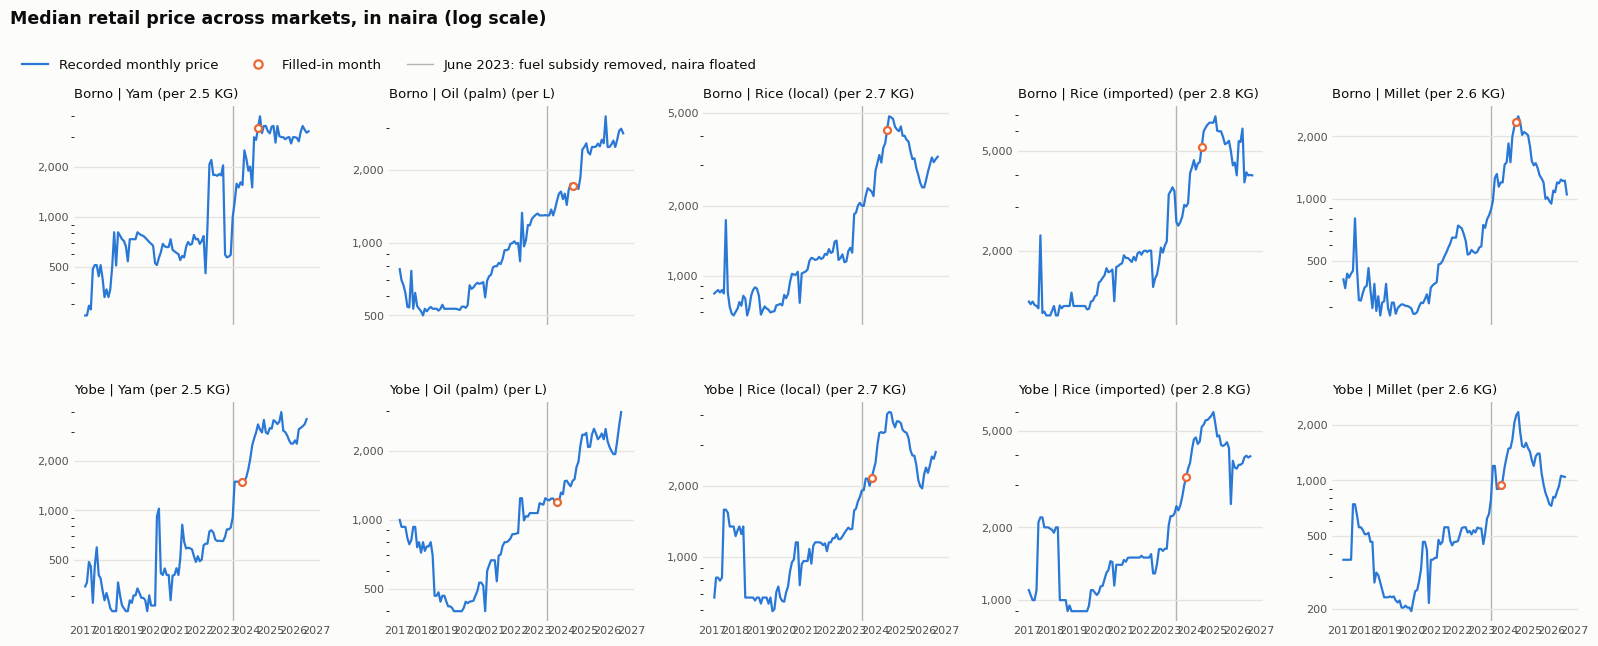

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

BLUE, ORANGE, INK, MUTED, GRID, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
SHOCK = pd.Timestamp("2023-06-01")                  

fig, axes = plt.subplots(2, 5, figsize=(16, 6.6), dpi=100, sharex=True)
fig.patch.set_facecolor(SURFACE)
for i, state in enumerate(["Borno", "Yobe"]):
    for j, food in enumerate(UNITS):
        ax, d = axes[i, j], panel[(panel.state == state) & (panel.food == food)]
        ax.set_facecolor(SURFACE)
        ax.axvline(SHOCK, color="#b5b4ae", lw=1, zorder=1)
        ax.plot(d.month, d.price, color=BLUE, lw=1.6, zorder=2)
        f = d[~d.observed]
        ax.plot(f.month, f.price, "o", ms=5, mfc=SURFACE, mec=ORANGE, mew=1.6, lw=0, zorder=3)
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_title(f"{state} | {food} (per {d.unit.iloc[0]})", fontsize=9.5, color=INK, loc="left")
        ax.grid(axis="y", color=GRID, lw=1); ax.tick_params(colors=MUTED, labelsize=8, length=0)
        for s in ax.spines.values():
            s.set_visible(False)

handles = [Line2D([], [], color=BLUE, lw=1.6, label="Recorded monthly price"),
           Line2D([], [], color=ORANGE, marker="o", mfc=SURFACE, mew=1.6, lw=0, label="Filled-in month"),
           Line2D([], [], color="#b5b4ae", lw=1, label="June 2023: fuel subsidy removed, naira floated")]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.01, 0.93), ncol=3, frameon=False, fontsize=9.5, labelcolor=INK)
fig.text(0.01, 0.965, "Median retail price across markets, in naira (log scale)", fontsize=12.5, weight="bold", color=INK)
fig.subplots_adjust(left=0.05, right=0.99, top=0.84, bottom=0.06, hspace=0.35, wspace=0.28)
fig.savefig("/kaggle/working/price_series.png", dpi=120, facecolor=SURFACE)
plt.show()

In [20]:
logp = np.log(panel.price)
trend = logp.groupby(panel.series).transform(lambda s: s.rolling(13, center=True).mean())    
panel["vs_trend"] = np.exp(logp - trend) - 1       

season = (panel[panel.observed].dropna(subset=["vs_trend"])
          .assign(cal_month=lambda d: d.month.dt.month)
          .pivot_table(index="food", columns="cal_month", values="vs_trend", aggfunc="median"))
season.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
print("Typical price in each calendar month, compared with the year's average (%, both states, real prices only):")
print((season * 100).round(1).to_string())

change = panel.groupby("series").price.transform(lambda p: p.pct_change())
print("\nTypical size of a month-to-month price change (%, ignoring direction):")
print((change.abs().groupby(panel.food).median() * 100).round(1).to_string())

Typical price in each calendar month, compared with the year's average (%, both states, real prices only):
                 Jan   Feb  Mar  Apr  May  Jun  Jul   Aug  Sep  Oct  Nov  Dec
food                                                                         
Millet          -4.9  -2.6  3.0  2.0  1.0  1.7  0.8   4.2  1.1 -7.6 -6.0 -7.4
Oil (palm)      -0.3   0.4  0.5 -1.1  0.8 -1.3  0.4  -0.7 -1.6 -2.3 -2.0  3.2
Rice (imported) -0.7   5.0  4.8  1.7  1.6 -1.5 -1.7   0.8  0.4 -3.0 -0.4  0.8
Rice (local)    -3.5  -0.5  2.6  2.9  4.7  1.9  0.5   0.4  2.5 -2.8 -3.1 -4.0
Yam             -4.3 -12.0 -3.4 -6.3  4.1  7.2  8.7  11.0  3.6  5.9 -2.9 -9.6

Typical size of a month-to-month price change (%, ignoring direction):
food
Millet             5.4
Oil (palm)         3.2
Rice (imported)    2.6
Rice (local)       4.0
Yam                6.7
